In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids
from colors import COLORS

In [8]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

FONT_SIZE = 12

keys = ["random", "so-smac", "mo-smac", "so-asha", "mo-asha", "nsga2"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.weight": "normal",
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,      # axis labels
    "axes.titlesize": FONT_SIZE,      # subplot titles
    "xtick.labelsize": FONT_SIZE,     # x tick labels
    "ytick.labelsize": FONT_SIZE,     # y tick labels
    "legend.fontsize": FONT_SIZE,     # legend
    "figure.titlesize": FONT_SIZE + 4     # suptitle
})

In [9]:
data = pd.read_csv("./data/raaml_results_gbmlp.csv")
print(list(data.columns))

['task_id', 'method', 'seed', 'config_id', 'model', 'time_5fcv', 'bmp_RMSE', 'bmp_inference_time', 'bmp_energy_consumption', 'status', 'ensembling_RMSE', 'ensembling_inference_time_freq_1500000_cores_1', 'ensembling_energy_consumption_freq_1500000_cores_1', 'ensembling_inference_time_freq_1500000_cores_2', 'ensembling_energy_consumption_freq_1500000_cores_2', 'ensembling_inference_time_freq_1500000_cores_3', 'ensembling_energy_consumption_freq_1500000_cores_3', 'ensembling_inference_time_freq_1500000_cores_4', 'ensembling_energy_consumption_freq_1500000_cores_4', 'ensembling_inference_time_freq_1500000_cores_5', 'ensembling_energy_consumption_freq_1500000_cores_5', 'ensembling_inference_time_freq_1500000_cores_6', 'ensembling_energy_consumption_freq_1500000_cores_6', 'ensembling_inference_time_freq_1500000_cores_7', 'ensembling_energy_consumption_freq_1500000_cores_7', 'ensembling_inference_time_freq_1500000_cores_8', 'ensembling_energy_consumption_freq_1500000_cores_8', 'ensembling_in

In [10]:
data_random = data[(data["method"] == "random") & (~np.isnan(data["ensembling_inference_time_freq_1500000_cores_1"]))]

In [11]:
COLOR_LIST = list(COLORS.values())

# Parallelization Tradeoffs

In [12]:
print(list(data_random.columns))

['task_id', 'method', 'seed', 'config_id', 'model', 'time_5fcv', 'bmp_RMSE', 'bmp_inference_time', 'bmp_energy_consumption', 'status', 'ensembling_RMSE', 'ensembling_inference_time_freq_1500000_cores_1', 'ensembling_energy_consumption_freq_1500000_cores_1', 'ensembling_inference_time_freq_1500000_cores_2', 'ensembling_energy_consumption_freq_1500000_cores_2', 'ensembling_inference_time_freq_1500000_cores_3', 'ensembling_energy_consumption_freq_1500000_cores_3', 'ensembling_inference_time_freq_1500000_cores_4', 'ensembling_energy_consumption_freq_1500000_cores_4', 'ensembling_inference_time_freq_1500000_cores_5', 'ensembling_energy_consumption_freq_1500000_cores_5', 'ensembling_inference_time_freq_1500000_cores_6', 'ensembling_energy_consumption_freq_1500000_cores_6', 'ensembling_inference_time_freq_1500000_cores_7', 'ensembling_energy_consumption_freq_1500000_cores_7', 'ensembling_inference_time_freq_1500000_cores_8', 'ensembling_energy_consumption_freq_1500000_cores_8', 'ensembling_in

In [13]:
def plot_parallel_tradeoff(data_random, frequency, plot_both=True):
    inf_times = np.zeros((len(data_random), 8))
    energies = np.zeros((len(data_random), 8))
    for cores in range(1, 9):
        inf_times[:, cores - 1] = data_random[f"ensembling_inference_time_freq_{frequency}_cores_{cores}"]
        energies[:, cores - 1] = data_random[f"ensembling_energy_consumption_freq_{frequency}_cores_{cores}"]
    #inf_times_norm = (inf_times - inf_times.min(axis=1, keepdims=True)) / (inf_times.max(axis=1, keepdims=True) - inf_times.min(axis=1, keepdims=True))
    #energies_norm = (energies - energies.min(axis=1, keepdims=True)) / (energies.max(axis=1, keepdims=True) - energies.min(axis=1, keepdims=True))
    inf_times_norm = inf_times / inf_times.max(axis=1, keepdims=True)
    energies_norm = energies / energies.max(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(14 if plot_both else 7, 9 if plot_both else 7), ncols=2 if plot_both else 1, nrows=3 if plot_both else 2)
    ax = ax.flatten()
    # Plot speedup as boxplot and plot
    data = []
    for i in range(8):
        for val in inf_times_norm[:, i]:
            data.append({"Cores": f"{i+1}", "Metric": "Inference Time", "Value": val})
        for val in energies_norm[:, i]:
            data.append({"Cores": f"{i+1}", "Metric": "Energy Consumption", "Value": val})
    df = pd.DataFrame(data)
    
    
    mean_inf_time = [np.mean(inf_times_norm[:, i]) for i in range(8)]
    mean_energy = [np.mean(energies_norm[:, i]) for i in range(8)]
    std_inf_time = [np.std(inf_times_norm[:, i]) for i in range(8)]
    std_energy = [np.std(energies_norm[:, i]) for i in range(8)]
    x = np.arange(8)
    speedup = inf_times[:, 0:1] / inf_times
    
    if not plot_both:
        ax = [None, ax[0], None, None, None, ax[1]]
    
    if plot_both:
        sns.boxplot(data=df, x="Cores", y="Value", hue="Metric", showfliers=False, ax=ax[0])
        ax[0].set_xlabel("Number of CPU Cores")
        ax[0].set_ylabel("Normalised Metric Value")
        ax[0].legend(title="Metric", loc='lower right',bbox_to_anchor=(1, 0.04))
        
    ax[1].plot(x, mean_inf_time, marker='o', label='Inference Time', color=COLOR_LIST[0])
    ax[1].fill_between(x, np.clip(np.array(mean_inf_time) - np.array(std_inf_time), 0, None), np.clip(np.array(mean_inf_time) + np.array(std_inf_time), None, 1), color=COLOR_LIST[0], alpha=0.2)
    ax[1].plot(x, mean_energy, marker='o', label='Energy Consumption', color=COLOR_LIST[1])
    ax[1].fill_between(x, np.clip(np.array(mean_energy) - np.array(std_energy), 0, None), np.clip(np.array(mean_energy) + np.array(std_energy), None, 1), color=COLOR_LIST[1], alpha=0.2)
    ax[1].set_xticks(x, [str(i+1) for i in range(8)])
    ax[1].set_xlabel("Number of CPU Cores")
    ax[1].set_ylabel("Max-Normalised\nMetric Value")
    ax[1].legend(title="Metric")

    mean_speedup = [np.mean(speedup[:, i]) for i in range(8)]
    std_speedup = [np.std(speedup[:, i]) for i in range(8)]
    
    if plot_both:
        sns.boxplot(data=speedup, ax=ax[2], showfliers=False, color=COLOR_LIST[3], label="Speedup")
        ax[2].set_xlabel("Number of CPU Cores")
        ax[2].set_ylabel("Speedup")
        ax[2].set_xticks(x, [str(i+1) for i in range(8)])
        ax[2].legend()

        ax[3].plot(x, mean_speedup, marker='o', label='Speedup', color=COLOR_LIST[3])
        ax[3].fill_between(x, np.array(mean_speedup) - np.array(std_speedup), np.array(mean_speedup) + np.array(std_speedup), color=COLOR_LIST[3], alpha=0.2)
        ax[3].set_xlabel("Number of CPU Cores")
        ax[3].set_ylabel("Mean Speedup")
        ax[3].set_xticks(x, [str(i+1) for i in range(8)])
        ax[3].legend()
    
    speedup_efficiency = speedup / (1 + x[np.newaxis, :])  # Efficiency = Speedup / Number of Cores
    if plot_both:
        sns.boxplot(data=speedup_efficiency, ax=ax[4], showfliers=False, color=COLOR_LIST[2], label="Parallelisation\nEfficiency")
        ax[4].set_xlabel("Number of CPU Cores")
        ax[4].set_ylabel("Parallelisation\nEfficiency")
        ax[4].set_xticks(x, [str(i+1) for i in range(8)])
        ax[4].legend()

    mean_efficiency = [np.mean(speedup_efficiency[:, i]) for i in range(8)]
    std_efficiency = [np.std(speedup_efficiency[:, i]) for i in range(8)]
    ax[5].plot(x, mean_efficiency, marker='o', label='Parallelisation\nEfficiency', color=COLOR_LIST[2])
    ax[5].fill_between(x, np.clip(np.array(mean_efficiency) - np.array(std_efficiency), 0, None), np.clip(np.array(mean_efficiency) + np.array(std_efficiency), None, 1), color=COLOR_LIST[2], alpha=0.2)
    ax[5].set_xlabel("Number of CPU Cores")
    ax[5].set_ylabel("Parallelisation\nEfficiency")
    ax[5].set_xticks(x, [str(i+1) for i in range(8)])
    ax[5].legend()
    plt.tight_layout()
    plt.savefig(f"./figures/4/parallel_tradeoff.pdf")

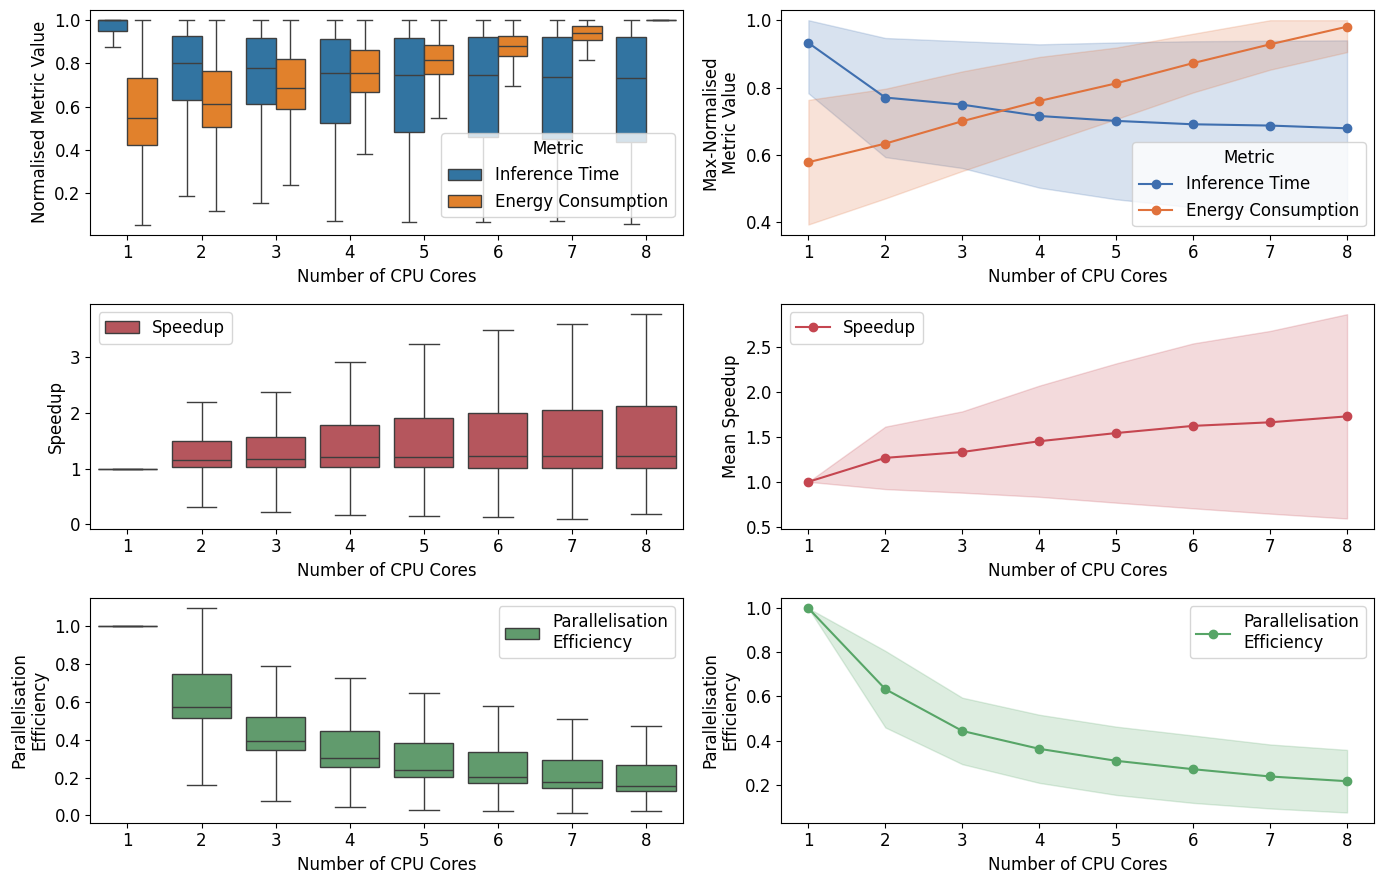

In [25]:
plot_parallel_tradeoff(data_random, frequency="boost")

# Consistency Analysis

In [14]:
print(data_random.columns)

Index(['task_id', 'method', 'seed', 'config_id', 'model', 'time_5fcv', 'bmp_RMSE', 'bmp_inference_time', 'bmp_energy_consumption', 'status',
       ...
       'final_inference_time_freq_boost_cores_7', 'final_energy_consumption_freq_boost_cores_7', 'final_inference_time_freq_boost_cores_8', 'final_energy_consumption_freq_boost_cores_8', 'bmp_Log Loss', 'ensembling_Log Loss', 'final_Log Loss', 'bmp_1 - ROC AUC', 'ensembling_1 - ROC AUC', 'final_1 - ROC AUC'], dtype='object', length=146)


In [15]:
data_by_cores_and_freqs = {}
for n_cores in range(1,9):
    for freq in [1500000, 2100000, 2800000, "boost"]:
        inf_times_ens = data_random[f"ensembling_inference_time_freq_{freq}_cores_{n_cores}"]
        inf_times_final = data_random[f"final_inference_time_freq_{freq}_cores_{n_cores}"]
        energies_ens = data_random[f"ensembling_energy_consumption_freq_{freq}_cores_{n_cores}"]
        energies_final = data_random[f"final_energy_consumption_freq_{freq}_cores_{n_cores}"]
        data_by_cores_and_freqs[(n_cores, freq)] = {
            "inf_times_ens": inf_times_ens,
            "inf_times_final": inf_times_final,
            "energies_ens": energies_ens,
            "energies_final": energies_final
        }

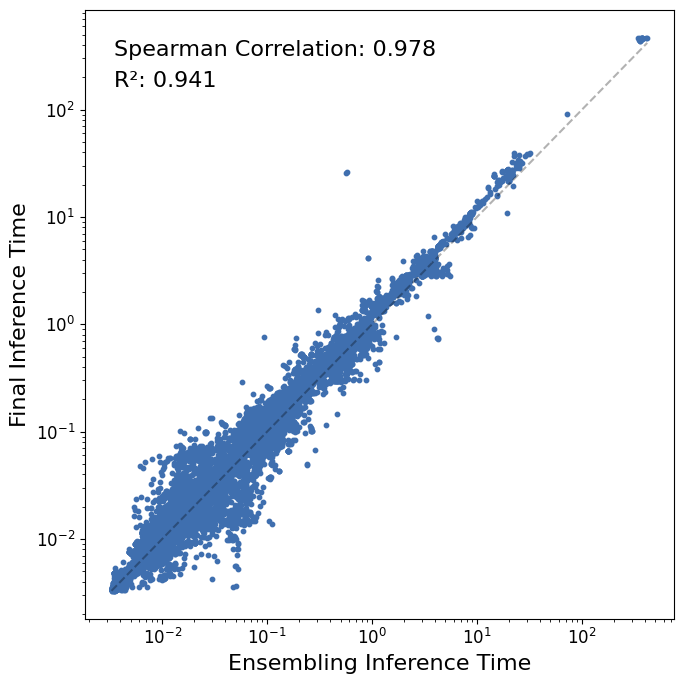

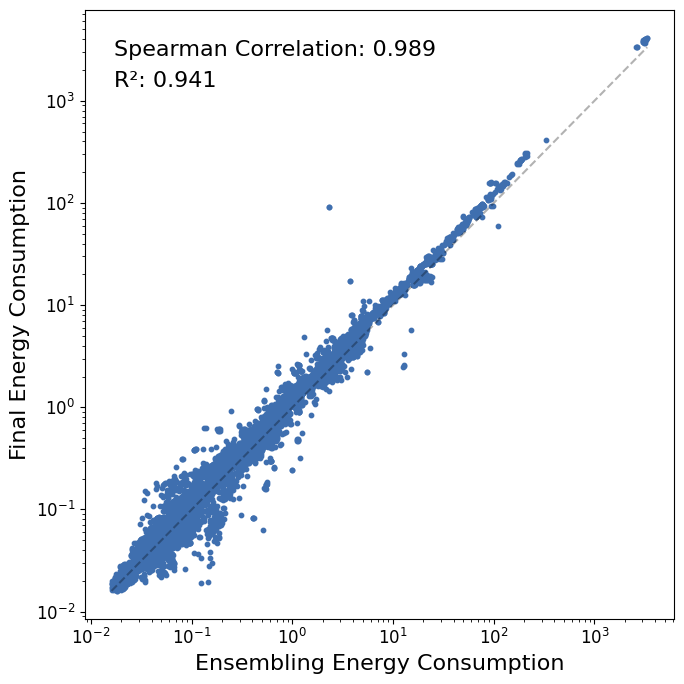

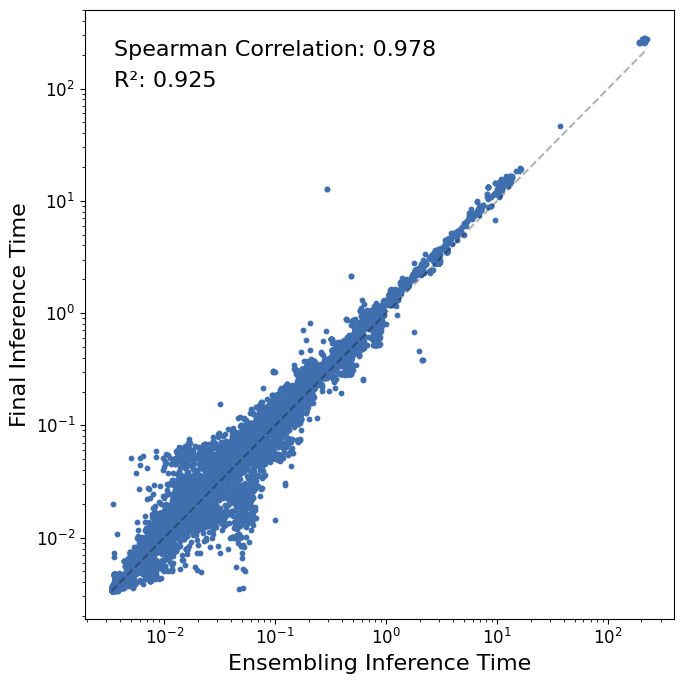

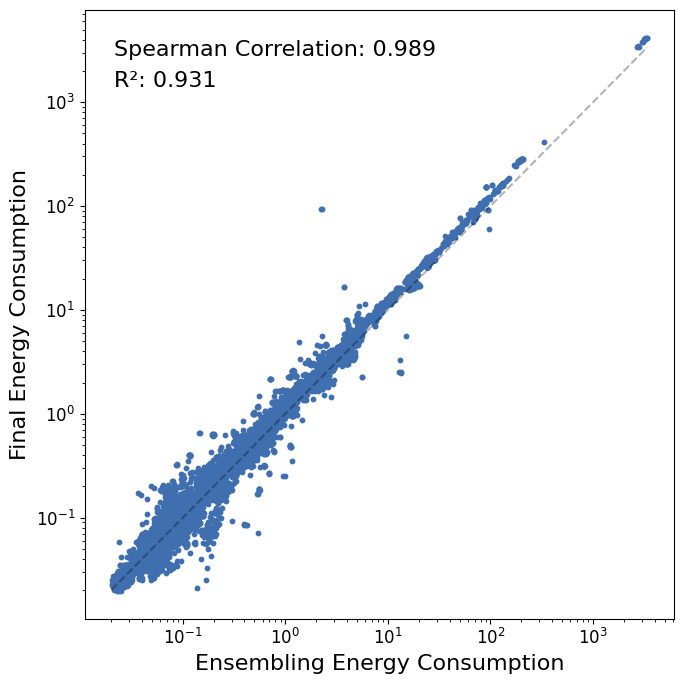

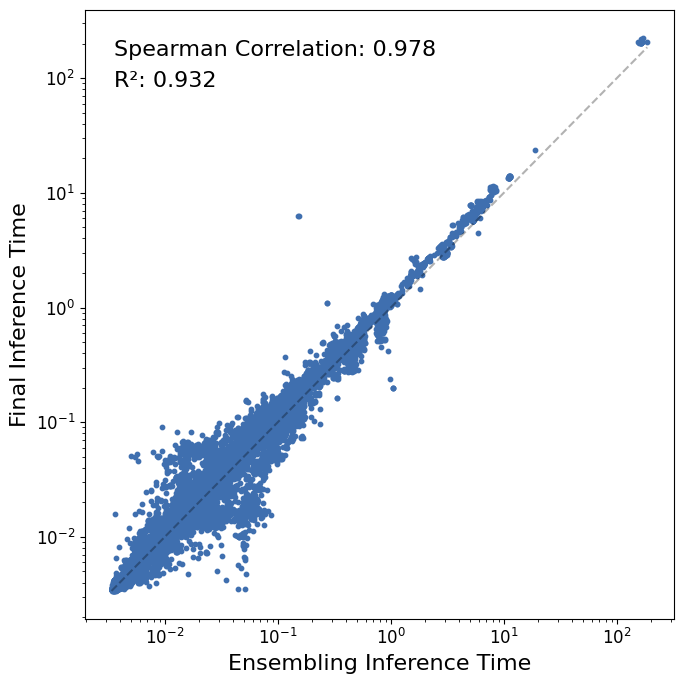

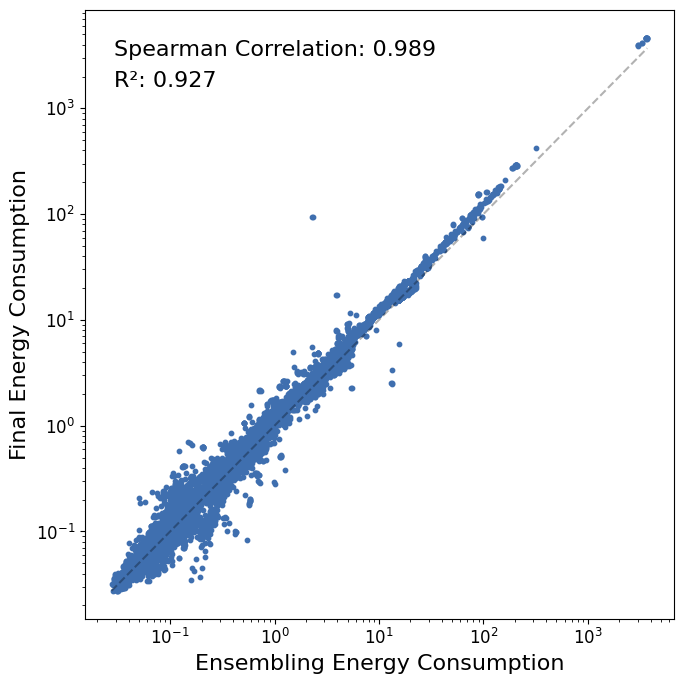

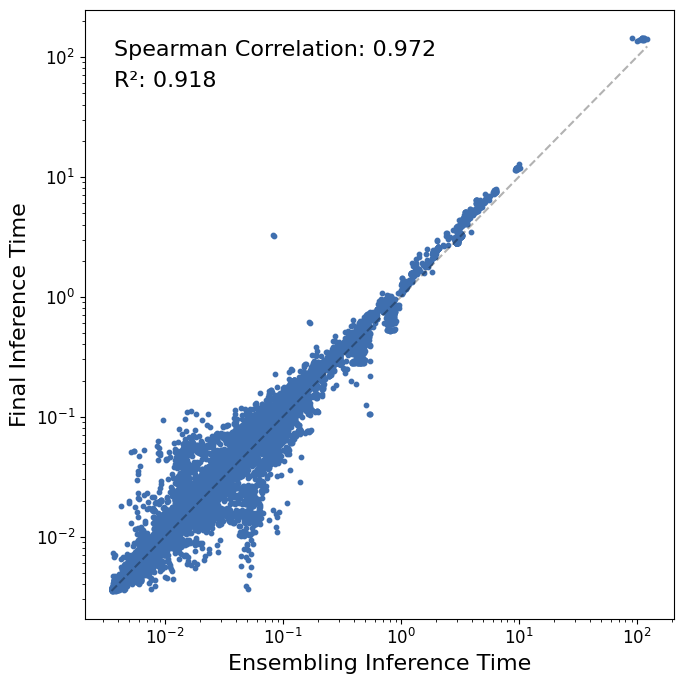

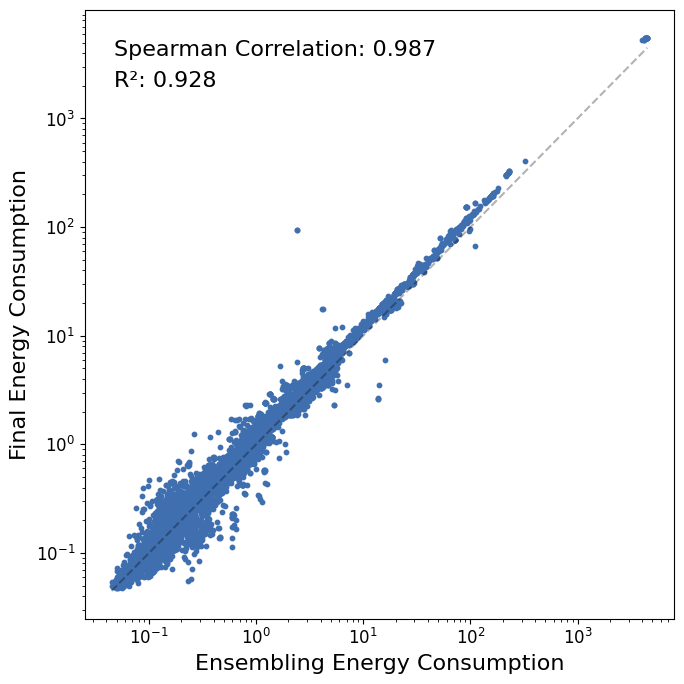

In [17]:
for n_cores in [1,2,4,8]:
    for freq in ["boost"]: 
        for i, metric in enumerate(["inf_times", "energies"]):
            fig, ax = plt.subplots(figsize=(7, 7))
            ens = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_ens"]
            final = data_by_cores_and_freqs[(n_cores, freq)][f"{metric}_final"]
            ax.scatter(ens, final, color=COLOR_LIST[0], s=10)
            ax.plot([ens.min(), ens.max()], [ens.min(), ens.max()], color='black', alpha=0.3, linestyle='--')
            ax.set_xlabel(f"Ensembling {'Inference Time' if metric == 'inf_times' else 'Energy Consumption'}",fontsize=16)
            ax.set_ylabel(f"Final {'Inference Time' if metric == 'inf_times' else 'Energy Consumption'}",fontsize=16)
            #ax[i].set_title(f"Ensembling vs. Final {metric.replace('_', ' ').title()} at {n_cores} Cores and {freq} Frequency")
            ax.set_xscale("log")
            ax.set_yscale("log")
            #corr = np.corrcoef(ens, final)[0, 1]
            #ax[i].text(0.05, 0.95, f"Pearson Correlation: {corr:.3f}", transform=ax[i].transAxes, verticalalignment='top', fontsize=14)
            r2 = r2_score(ens, final)
            ax.text(0.05, 0.9, f"R²: {r2:.3f}", transform=ax.transAxes, verticalalignment='top', fontsize=16)
            spearman_corr, _ = spearmanr(ens, final)
            ax.text(0.05, 0.95, f"Spearman Correlation: {spearman_corr:.3f}", transform=ax.transAxes, verticalalignment='top', fontsize=16)
            plt.tight_layout()
            plt.savefig(f"./figures/4/consistency_{metric}_{n_cores}.pdf")